<a href="https://colab.research.google.com/github/14marcos1/projeto2026/blob/main/projeto2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# =========================================
# 0) SETUP (rode esta célula)
# =========================================
!pip -q install pandas numpy scikit-learn matplotlib seaborn openpyxl

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.impute import SimpleImputer

plt.rcParams["figure.dpi"] = 140

In [3]:
!pip -q install python-docx pandas numpy
from google.colab import files
uploaded = files.upload()
docx_path = list(uploaded.keys())[0]


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 253.0/253.0 kB 5.3 MB/s eta 0:00:00


Saving Tabela sobre a composição por CG-EM.docx to Tabela sobre a composição por CG-EM.docx


In [4]:
import pandas as pd, numpy as np
from docx import Document

doc = Document(docx_path)
tables = []
for t in doc.tables:
    rows = [[cell.text.strip() for cell in row.cells] for row in t.rows]
    tables.append(pd.DataFrame(rows))

sizes = [(i, df.shape) for i, df in enumerate(tables)]
sizes

[(0, (24, 12)), (1, (11, 14)), (2, (8, 2))]

In [5]:
i = max(range(len(tables)), key=lambda k: tables[k].shape[0]*tables[k].shape[1])
df = tables[i].copy()
df.head()

,0,1,2,3,4,5,6,7,8,9,10,11
0,Composto,Teor (mg/mL),Teor (mg/mL),Teor (mg/mL),,,,,,,,
1,,OCV,OCC,OCB,OCC-TC,OCC-TM,OCC-TE,OCC-TME,OCV-B,OCB-B,OC-BD,OC-BR
2,Ácido palmitico,"1,81","0,50","1,94","0,78","1,90","2,41","3,68","4,76","3,09","0,71","0,89"
3,Cafeína,"0,37","0,31","0,35","0,25","0,36","0,43","0,64","1,01","0,56","0,22","0,36"
4,Ácido linoleico,"1,01","0,44","0,99","0,85","1,38","1,47","1,21","1,71","1,00","0,74","1,58"


In [6]:
import numpy as np
import pandas as pd

# 1) reconstruir cabeçalho: linha 0 = títulos; linha 1 = nomes das amostras
amostras = df.iloc[1, 1:].tolist()                  # OCV, OCC, ...
df2 = df.iloc[2:, :].copy()                         # dados começam na linha 2
df2.columns = ["Composto"] + amostras               # define colunas
df2 = df2.set_index("Composto")

# 2) limpeza: "_" -> NaN; vírgula decimal -> ponto; converte para numérico
df2 = df2.replace("_", np.nan)
df2 = df2.applymap(lambda x: str(x).strip().replace(",", ".") if pd.notna(x) else x)
df_num = df2.apply(pd.to_numeric, errors="coerce")

print(df_num.shape)
display(df_num.head())

# 3) salvar tabela limpa
df_num.to_csv("tabela1_limpa.csv", index=True)
from google.colab import files
files.download("tabela1_limpa.csv")

(22, 11)


/tmp/ipykernel_306/3322536348.py:12: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  df2 = df2.applymap(lambda x: str(x).strip().replace(",", ".") if pd.notna(x) else x)


,OCV,OCC,OCB,OCC-TC,OCC-TM,OCC-TE,OCC-TME,OCV-B,OCB-B,OC-BD,OC-BR
Composto,,,,,,,,,,,
Ácido palmitico,1.81,0.50,1.94,0.78,1.90,2.41,3.68,4.76,3.09,0.71,0.89
Cafeína,0.37,0.31,0.35,0.25,0.36,0.43,0.64,1.01,0.56,0.22,0.36
Ácido linoleico,1.01,0.44,0.99,0.85,1.38,1.47,1.21,1.71,1.00,0.74,1.58
Caveol,0.24,1.95,1.91,3.51,3.30,3.34,2.15,0.32,0.36,0.38,0.34
Cafestol,0.83,0.71,0.71,3.52,8.09,10.91,10.99,1.02,0.81,0.80,1.24


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [9]:
import numpy as np
import pandas as pd
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

# amostras nas linhas
X = df_num.T  # (amostras x compostos)

# 1) checar onde tem NaN
print("Total de NaN:", X.isna().sum().sum())
display(X.isna().sum().sort_values(ascending=False).head(10))

# 2) imputação por mediana (por composto/coluna)
imp = SimpleImputer(strategy="median")
X_imp = pd.DataFrame(imp.fit_transform(X), index=X.index, columns=X.columns)

# 3) z-score por composto
Z = StandardScaler().fit_transform(X_imp)

# guarda pronto para PCA
X_pca = Z
print("OK: NaN depois da imputação =", np.isnan(X_pca).sum())

Total de NaN: 9


,0
Composto,
1-palmitoil-2-stearoil-3-linoleoil-glicerol (PSL),6
1-palmitoil-2-oleoil-3-linoleoil-glicerol (POL),2
"1,2-dilinoleoil-3-linolenoil-glicerol (LLLn)",1
Ácido linoleico,0
Ácido palmitico,0
Cafeína,0
Tocoferol,0
Cafestol,0
Caveol,0


OK: NaN depois da imputação = 0


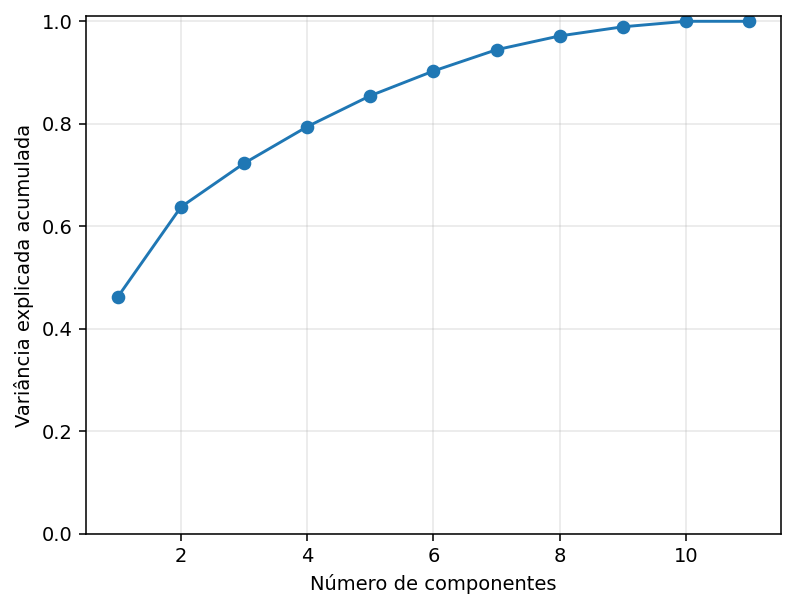

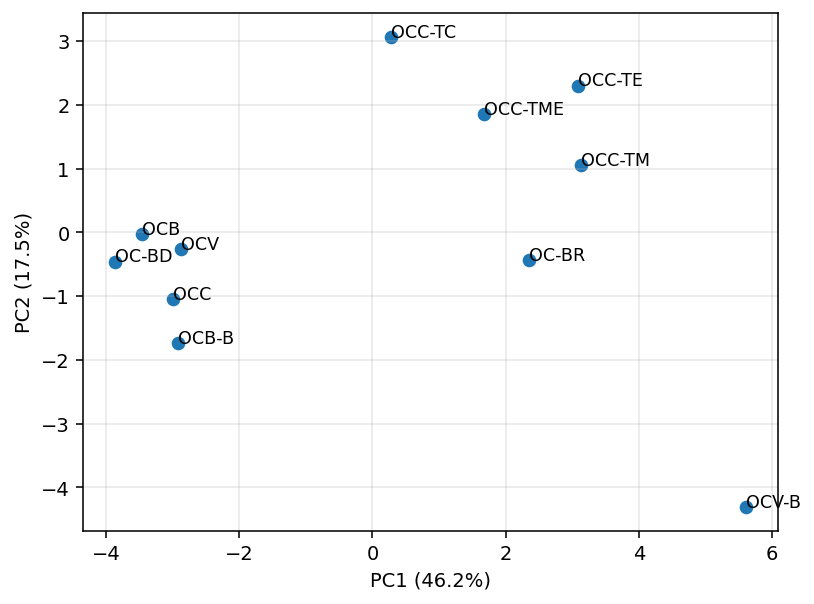

Top 10 (|loading|) em PC1:


,PC1,PC2
Composto,,
β-sitosterol,0.295304,0.009384
Estigmasterol,0.285149,-0.092740
"1-palmitoil-2,3-dilinoleoil-glicerol (PLL)",0.283797,0.129317
"1,2-dipalmitoll-3-linoleoll glicerol (PPL)",0.281266,0.107450
"1,2-dilinoleoil-3-linolenoil-glicerol (LLLn)",0.271114,-0.174521
Ácido linoleico,0.267661,-0.076964
1-estearoil-2-linoleoil-3-linolenoil-glicerol (SLLn),0.266328,-0.233505
1-estearoil-2-oleoil-3-linoleoil-glicerol (SOL),0.262100,-0.141600
1-palmitoil-2-linoleoil-3-araquidonil-glicerol (PLA),0.244440,0.110858


Top 10 (|loading|) em PC2:


,PC1,PC2
Composto,,
Caveol,0.084310,0.393059
Cafestol,0.164546,0.332440
Cafeína,0.183926,-0.295414
"1,2-dipalmitoil-3-oleoil-glicerol (PPO",0.233812,0.285306
"1,2,3-tripalmitoil-glicerol (PPP)",0.233812,0.285306
Palmitato de cafestol,-0.036190,-0.241220
Palmitato de caveol,0.000578,-0.241165
1-estearoil-2-linoleoil-3-linolenoil-glicerol (SLLn),0.266328,-0.233505
Campesterol,0.116398,-0.231818


In [10]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.decomposition import PCA

pca = PCA(n_components=min(X_pca.shape))
scores = pca.fit_transform(X_pca)
expl = pca.explained_variance_ratio_

plt.figure()
plt.plot(np.arange(1, len(expl)+1), np.cumsum(expl), marker="o")
plt.xlabel("Número de componentes")
plt.ylabel("Variância explicada acumulada")
plt.ylim(0, 1.01)
plt.grid(True, alpha=0.3)
plt.show()

plt.figure()
plt.scatter(scores[:,0], scores[:,1])
for i, name in enumerate(df_num.columns):
    plt.text(scores[i,0], scores[i,1], name, fontsize=9)
plt.xlabel(f"PC1 ({expl[0]*100:.1f}%)")
plt.ylabel(f"PC2 ({expl[1]*100:.1f}%)")
plt.grid(True, alpha=0.3)
plt.show()

loadings = pd.DataFrame(
    {"PC1": pca.components_[0], "PC2": pca.components_[1]},
    index=df_num.index
)
print("Top 10 (|loading|) em PC1:")
display(loadings.loc[loadings["PC1"].abs().sort_values(ascending=False).head(10).index])

print("Top 10 (|loading|) em PC2:")
display(loadings.loc[loadings["PC2"].abs().sort_values(ascending=False).head(10).index])

1) Dendrograma (Ward) + Heatmap (top variância)

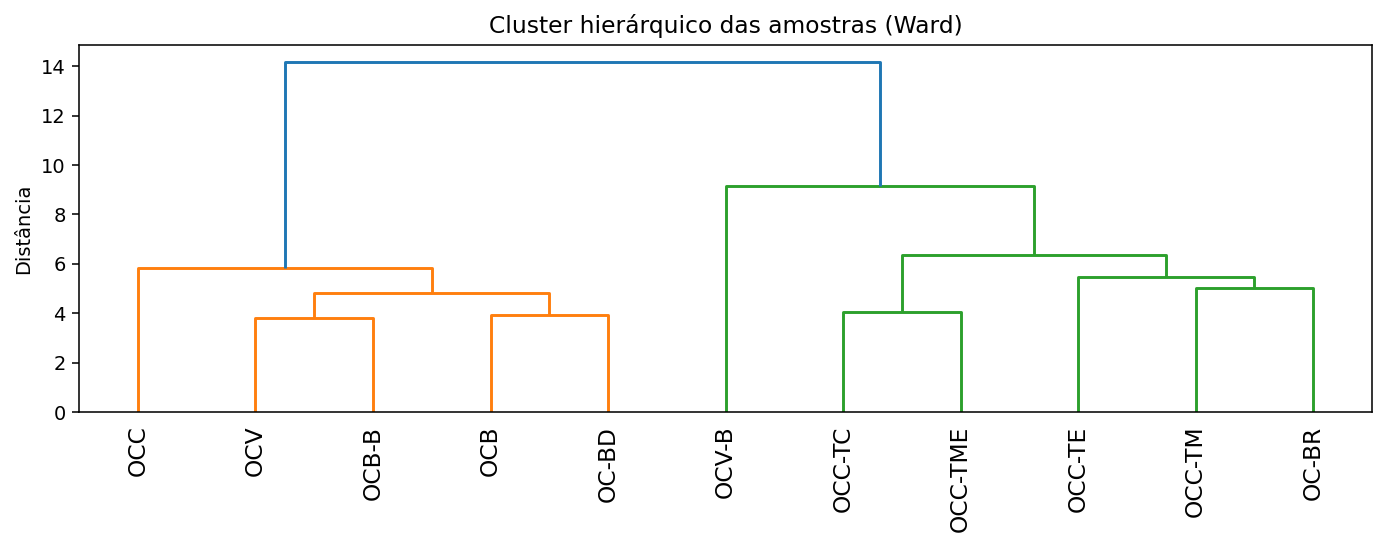

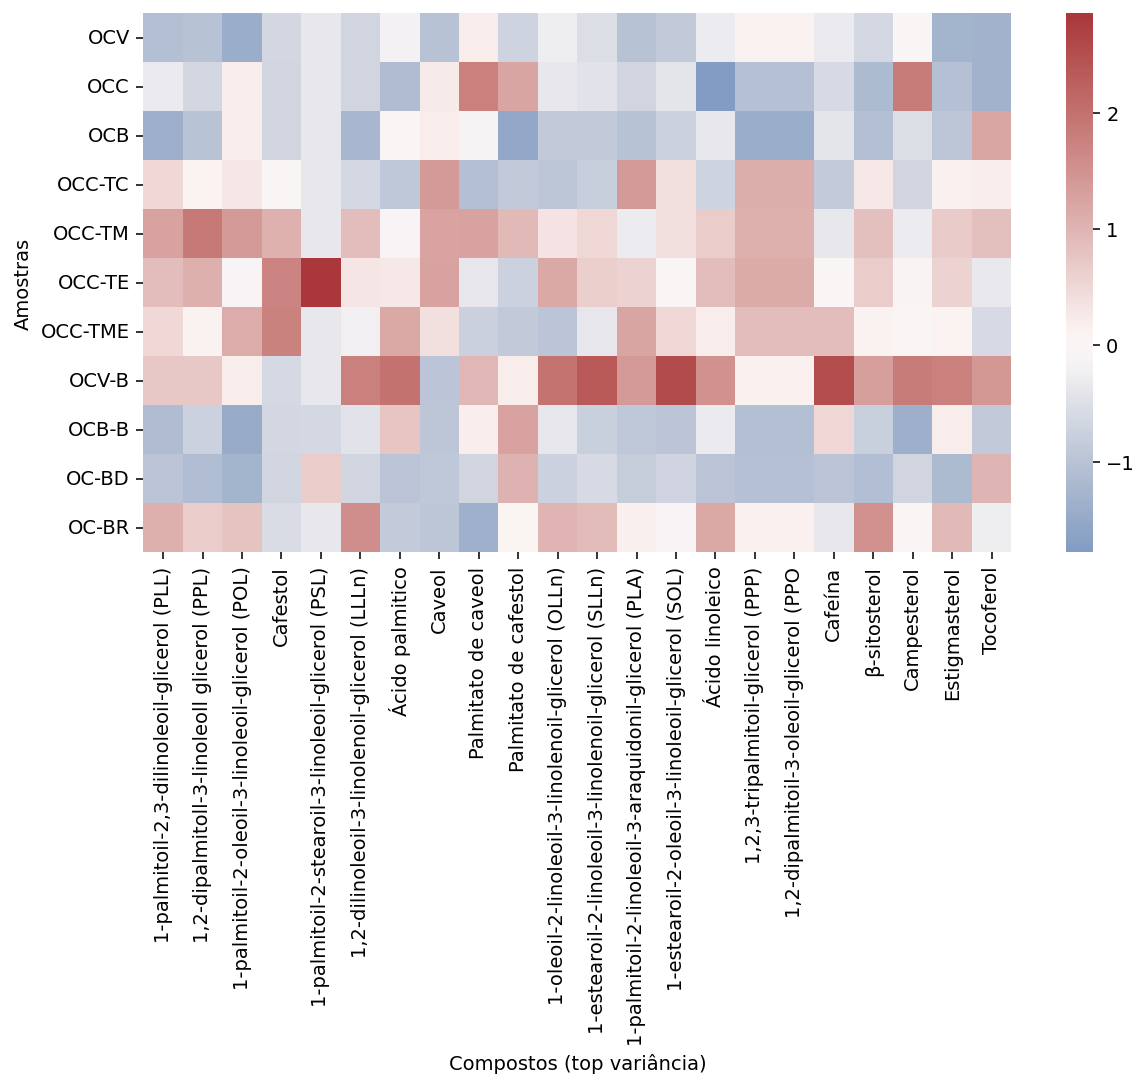

In [11]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from scipy.cluster.hierarchy import linkage, dendrogram

# matriz amostras x compostos
X = df_num.T

# imputa NaN por mediana
X_imp = pd.DataFrame(
    SimpleImputer(strategy="median").fit_transform(X),
    index=X.index, columns=X.columns
)

# padroniza por composto
Z = StandardScaler().fit_transform(X_imp)

# --- Dendrograma ---
L = linkage(Z, method="ward")
plt.figure(figsize=(10, 4))
dendrogram(L, labels=X_imp.index.tolist(), leaf_rotation=90)
plt.title("Cluster hierárquico das amostras (Ward)")
plt.ylabel("Distância")
plt.tight_layout()
plt.show()

# --- Heatmap: top N compostos mais variáveis ---
N = min(25, df_num.shape[0])
top_var = df_num.var(axis=1).sort_values(ascending=False).head(N).index

X_hm = X_imp[top_var]
X_hm_z = (X_hm - X_hm.mean(axis=0)) / X_hm.std(axis=0)

plt.figure(figsize=(10, 5))
sns.heatmap(X_hm_z, center=0, cmap="vlag")
plt.xlabel("Compostos (top variância)")
plt.ylabel("Amostras")
plt.show()

2) ML supervisionado: Random Forest (cru vs torrado) + importância dos compostos

In [12]:
import numpy as np
import pandas as pd
from sklearn.model_selection import LeaveOneOut, cross_val_score
from sklearn.ensemble import RandomForestClassifier

# features
X = df_num.T
X_imp = pd.DataFrame(
    SimpleImputer(strategy="median").fit_transform(X),
    index=X.index, columns=X.columns
)

# rótulo: torrado = OCC-TC/TM/TE/TME; resto = cru/outros
roasted = {"OCC-TC","OCC-TM","OCC-TE","OCC-TME"}
y = X_imp.index.to_series().apply(lambda s: 1 if s in roasted else 0).values  # 1=torrado

# modelo (sem tuning, só baseline interpretável)
rf = RandomForestClassifier(
    n_estimators=1000,
    random_state=42,
    class_weight="balanced"
)

# validação (Leave-One-Out porque n=11)
loo = LeaveOneOut()
acc = cross_val_score(rf, X_imp.values, y, cv=loo, scoring="accuracy").mean()
print(f"Acurácia LOOCV (cru vs torrado): {acc:.2f}")

# treina no conjunto completo para extrair importâncias
rf.fit(X_imp.values, y)
imp = pd.Series(rf.feature_importances_, index=X_imp.columns).sort_values(ascending=False)

print("\nTop 15 compostos mais importantes para separar cru vs torrado:")
display(imp.head(15).to_frame("importância"))

Acurácia LOOCV (cru vs torrado): 1.00

Top 15 compostos mais importantes para separar cru vs torrado:


,importância
Composto,
Cafestol,0.152721
Caveol,0.138099
"1,2,3-tripalmitoil-glicerol (PPP)",0.134723
"1,2-dipalmitoil-3-oleoil-glicerol (PPO",0.129202
1-estearoil-2-oleoil-3-linoleoil-glicerol (SOL),0.073936
"1,2-dipalmitoll-3-linoleoll glicerol (PPL)",0.041433
β-sitosterol,0.040808
1-palmitoil-2-oleoil-3-linoleoil-glicerol (POL),0.035127
1-palmitoil-2-linoleoil-3-araquidonil-glicerol (PLA),0.034828


0) Base (imputação + padronização) e checagens

In [13]:
import numpy as np
import pandas as pd

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

# matriz amostras x compostos
X = df_num.T

# imputação por mediana
X_imp = pd.DataFrame(SimpleImputer(strategy="median").fit_transform(X),
                     index=X.index, columns=X.columns)

# padronização z-score por composto
Z = pd.DataFrame(StandardScaler().fit_transform(X_imp),
                 index=X_imp.index, columns=X_imp.columns)

# checagens rápidas
desc = X_imp.describe().T
desc["CV_%"] = (desc["std"] / desc["mean"] * 100)
display(desc.sort_values("CV_%", ascending=False).head(10))  # mais variáveis

# correlação (para ver blocos/colinearidade)
corr = X_imp.corr()

,count,mean,std,min,25%,50%,75%,max,CV_%
Composto,,,,,,,,,
Cafestol,11.0,3.602727,4.247844,0.71,0.805,1.02,5.805,10.99,117.906354
1-palmitoil-2-stearoil-3-linoleoil-glicerol (PSL),11.0,1.253636,1.315928,0.43,0.780,0.78,0.780,5.01,104.968844
Caveol,11.0,1.618182,1.348509,0.24,0.350,1.91,2.725,3.51,83.334822
1-oleoil-2-linoleoil-3-linolenoil-glicerol (OLLn),11.0,1.680000,1.193214,0.53,0.705,1.25,2.495,4.04,71.024652
1-estearoil-2-oleoil-3-linoleoil-glicerol (SOL),11.0,0.590909,0.416472,0.19,0.290,0.55,0.755,1.65,70.479910
Ácido palmitico,11.0,2.042727,1.358691,0.50,0.835,1.90,2.750,4.76,66.513589
1-estearoil-2-linoleoil-3-linolenoil-glicerol (SLLn),11.0,1.770000,1.101063,0.79,1.020,1.29,2.415,4.35,62.206956
β-sitosterol,11.0,0.342727,0.209432,0.10,0.150,0.37,0.500,0.66,61.107519
1-palmitoil-2-oleoil-3-linoleoil-glicerol (POL),11.0,11.674545,6.804703,1.58,6.950,13.21,15.400,21.22,58.286666


1) Outliers por amostra (distância robusta no espaço padronizado)

,MD2_PCA,flag_outlier
OCV-B,7.358287,False
OCC,6.655836,False
OCC-TM,3.369927,False
OCC-TC,2.275009,False
OCC-TE,2.111422,False
OCB-B,1.895806,False
OCB,1.716299,False
OCC-TME,1.639864,False
OC-BD,1.457130,False
OCV,0.936890,False


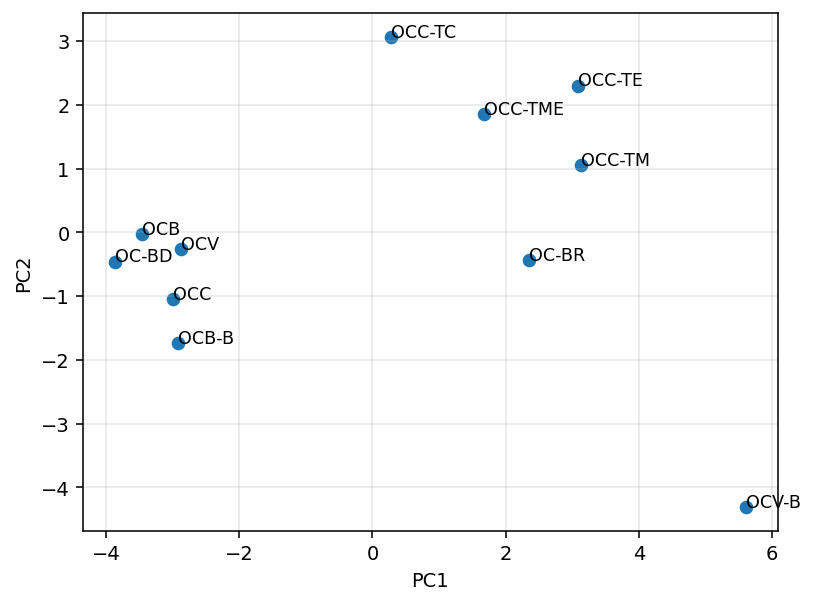

In [16]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from scipy.stats import chi2

# 1) matriz amostras x compostos
X = df_num.T
X_imp = pd.DataFrame(SimpleImputer(strategy="median").fit_transform(X),
                     index=X.index, columns=X.columns)
Z = StandardScaler().fit_transform(X_imp)

# 2) PCA e escolhe k PCs (use k=2 ou 3; com n=11, não passe disso para robustez)
pca = PCA(n_components=3, random_state=42)
S = pca.fit_transform(Z)  # scores (amostras x PCs)

k = 3
md2 = np.sum((S[:, :k] / S[:, :k].std(axis=0, ddof=1))**2, axis=1)  # distância tipo Mahalanobis no espaço PC
md2_s = pd.Series(md2, index=X_imp.index).sort_values(ascending=False)

thr = chi2.ppf(0.975, df=k)
out = pd.DataFrame({"MD2_PCA": md2_s, "flag_outlier": md2_s > thr})
display(out)

# 3) gráfico simples (PC1 x PC2) destacando o possível outlier
plt.figure()
plt.scatter(S[:,0], S[:,1])
for i, name in enumerate(X_imp.index):
    plt.text(S[i,0], S[i,1], name, fontsize=9)
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.grid(True, alpha=0.3)
plt.show()

In [17]:
import numpy as np
import pandas as pd
from sklearn.impute import SimpleImputer

X = df_num.T
X_imp = pd.DataFrame(SimpleImputer(strategy="median").fit_transform(X),
                     index=X.index, columns=X.columns)

Z = (X_imp - X_imp.mean(axis=0)) / X_imp.std(axis=0, ddof=1)
extremos = (Z.abs() > 2.5).sum(axis=1)  # quantos compostos estão >2.5 sd
display(extremos.sort_values(ascending=False).to_frame("n_extremos_|z|>2.5"))

,n_extremos_|z|>2.5
OCV-B,2
OCC-TE,1
OCV,0
OCB,0
OCC,0
OCC-TM,0
OCC-TC,0
OCC-TME,0
OCB-B,0
OC-BD,0


1) Testes de diferença + tamanho de efeito (cru vs torrado; brocado vs não; Rio vs Dura)

In [18]:
import numpy as np
import pandas as pd
from sklearn.impute import SimpleImputer
from scipy.stats import mannwhitneyu

X = df_num.T
X_imp = pd.DataFrame(SimpleImputer(strategy="median").fit_transform(X),
                     index=X.index, columns=X.columns)

def group_test(groupA, groupB, nameA="A", nameB="B"):
    gA = X_imp.loc[groupA]
    gB = X_imp.loc[groupB]
    rows = []
    for comp in X_imp.columns:
        a = gA[comp].values
        b = gB[comp].values
        stat, p = mannwhitneyu(a, b, alternative="two-sided")
        medA, medB = np.median(a), np.median(b)
        rows.append([comp, medA, medB, medA-medB, np.log2((medA+1e-9)/(medB+1e-9)), p])
    res = pd.DataFrame(rows, columns=["Composto",f"Med_{nameA}",f"Med_{nameB}","Δmed","log2FC","p"])
    return res.sort_values("p")

# (i) cru vs torrado
roasted = ["OCC-TC","OCC-TM","OCC-TE","OCC-TME"]
non_roasted = [s for s in X_imp.index if s not in roasted]
res_roast = group_test(roasted, non_roasted, "Torrado", "NaoTorrado")
display(res_roast.head(15))

# (ii) brocado vs não brocado (crus)
brocado = ["OCV-B","OCB-B"]
nao_broc = ["OCV","OCB","OCC"]
res_broca = group_test(brocado, nao_broc, "Brocado", "NaoBrocado")
display(res_broca.head(15))

# (iii) Rio vs Dura
res_rio_dura = group_test(["OC-BR"], ["OC-BD"], "Rio", "Dura")
display(res_rio_dura.head(15))

,Composto,Med_Torrado,Med_NaoTorrado,Δmed,log2FC,p
3,Caveol,3.320,0.36,2.960,3.205114,0.006061
11,"1,2,3-tripalmitoil-glicerol (PPP)",1.275,0.60,0.675,1.087463,0.010379
12,"1,2-dipalmitoil-3-oleoil-glicerol (PPO",1.275,0.60,0.675,1.087463,0.010379
4,Cafestol,9.500,0.81,8.690,3.551934,0.010556
13,"1,2-dipalmitoll-3-linoleoll glicerol (PPL)",34.360,14.92,19.440,1.203483,0.072727
18,1-estearoil-2-oleoil-3-linoleoil-glicerol (SOL),0.755,0.30,0.455,1.331514,0.072727
17,1-palmitoil-2-linoleoil-3-araquidonil-glicerol...,1.200,0.47,0.730,1.352302,0.087521
15,1-palmitoil-2-oleoil-3-linoleoil-glicerol (POL),16.485,13.21,3.275,0.319523,0.104985
16,"1-palmitoil-2,3-dilinoleoil-glicerol (PLL)",48.035,15.93,32.105,1.592340,0.109091
10,Palmitato de cafestol,5.315,6.63,-1.315,-0.318939,0.230303


,Composto,Med_Brocado,Med_NaoBrocado,Δmed,log2FC,p
0,Ácido palmitico,3.925,1.81,2.115,1.116703,0.200000
1,Cafeína,0.785,0.35,0.435,1.165338,0.200000
7,Estigmasterol,0.460,0.12,0.340,1.938599,0.200000
21,"1,2-dilinoleoil-3-linolenoil-glicerol (LLLn)",3.470,1.61,1.860,1.107875,0.200000
5,Tocoferol,0.645,0.43,0.215,0.584962,0.374259
4,Cafestol,0.915,0.71,0.205,0.365953,0.374259
17,1-palmitoil-2-linoleoil-3-araquidonil-glicerol...,0.920,0.38,0.540,1.275634,0.374259
2,Ácido linoleico,1.355,0.99,0.365,0.452792,0.400000
13,"1,2-dipalmitoll-3-linoleoll glicerol (PPL)",25.600,11.18,14.420,1.195224,0.400000
8,β-sitosterol,0.400,0.12,0.280,1.736966,0.400000


,Composto,Med_Rio,Med_Dura,Δmed,log2FC,p
0,Ácido palmitico,0.89,0.71,0.18,0.325986,1.0
1,Cafeína,0.36,0.22,0.14,0.710493,1.0
2,Ácido linoleico,1.58,0.74,0.84,1.094327,1.0
3,Caveol,0.34,0.38,-0.04,-0.160465,1.0
4,Cafestol,1.24,0.80,0.44,0.632268,1.0
5,Tocoferol,0.57,0.74,-0.17,-0.376563,1.0
6,Campesterol,0.37,0.26,0.11,0.509014,1.0
7,Estigmasterol,0.45,0.10,0.35,2.169925,1.0
8,β-sitosterol,0.66,0.11,0.55,2.584962,1.0
9,Palmitato de caveol,5.29,6.22,-0.93,-0.233647,1.0


2) PLS-DA + VIP (marcadores interpretáveis de torra)

In [19]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.cross_decomposition import PLSRegression
from sklearn.model_selection import LeaveOneOut
from sklearn.metrics import accuracy_score

# dados padronizados
Z = pd.DataFrame(StandardScaler().fit_transform(X_imp),
                 index=X_imp.index, columns=X_imp.columns)

y = Z.index.to_series().apply(lambda s: 1 if s in roasted else 0).values.astype(float)

def plsda_loocv(ncomp):
    loo = LeaveOneOut()
    yhat = np.zeros_like(y)
    for tr, te in loo.split(Z):
        pls = PLSRegression(n_components=ncomp)
        pls.fit(Z.iloc[tr].values, y[tr])
        yhat[te] = pls.predict(Z.iloc[te].values).ravel()
    pred = (yhat >= 0.5).astype(int)
    return accuracy_score(y.astype(int), pred)

scores = [(k, plsda_loocv(k)) for k in range(1, 6)]
display(pd.DataFrame(scores, columns=["n_components","LOOCV_acc"]))

best_k = max(scores, key=lambda x: x[1])[0]
pls = PLSRegression(n_components=best_k).fit(Z.values, y)

# VIP
T, W, Q = pls.x_scores_, pls.x_weights_, pls.y_loadings_
p, h = W.shape
s = np.sum((T**2) * (Q**2), axis=0)
vip = np.sqrt(p * (W**2 @ s) / np.sum(s))
vip = pd.Series(vip, index=Z.columns).sort_values(ascending=False)

display(vip.head(20).to_frame("VIP"))

,n_components,LOOCV_acc
0,1,0.818182
1,2,0.818182
2,3,0.909091
3,4,0.909091
4,5,0.909091


,VIP
Composto,
Cafestol,1.667403
Caveol,1.658509
"1,2,3-tripalmitoil-glicerol (PPP)",1.507016
"1,2-dipalmitoil-3-oleoil-glicerol (PPO",1.507016
"1,2-dipalmitoll-3-linoleoll glicerol (PPL)",1.163749
"1-palmitoil-2,3-dilinoleoil-glicerol (PLL)",1.159201
1-palmitoil-2-linoleoil-3-araquidonil-glicerol (PLA),1.063462
1-palmitoil-2-oleoil-3-linoleoil-glicerol (POL),0.992121
β-sitosterol,0.927240


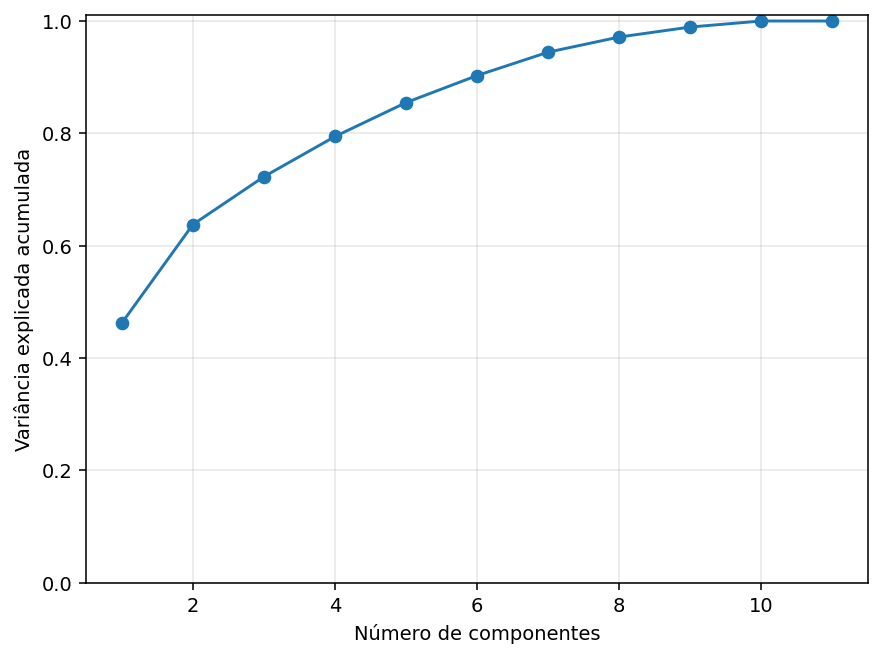

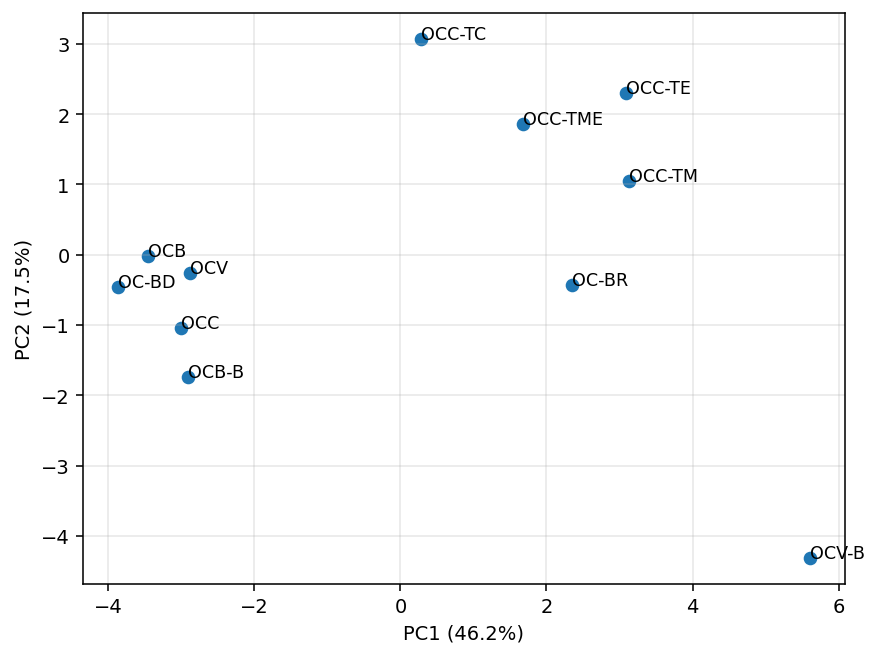

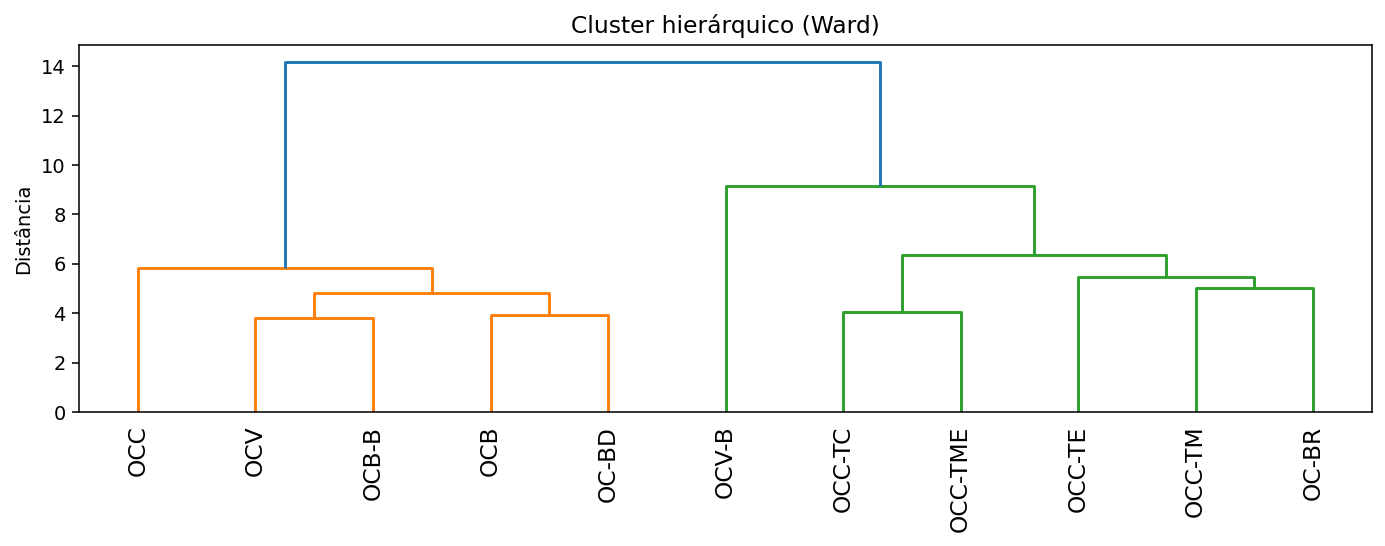

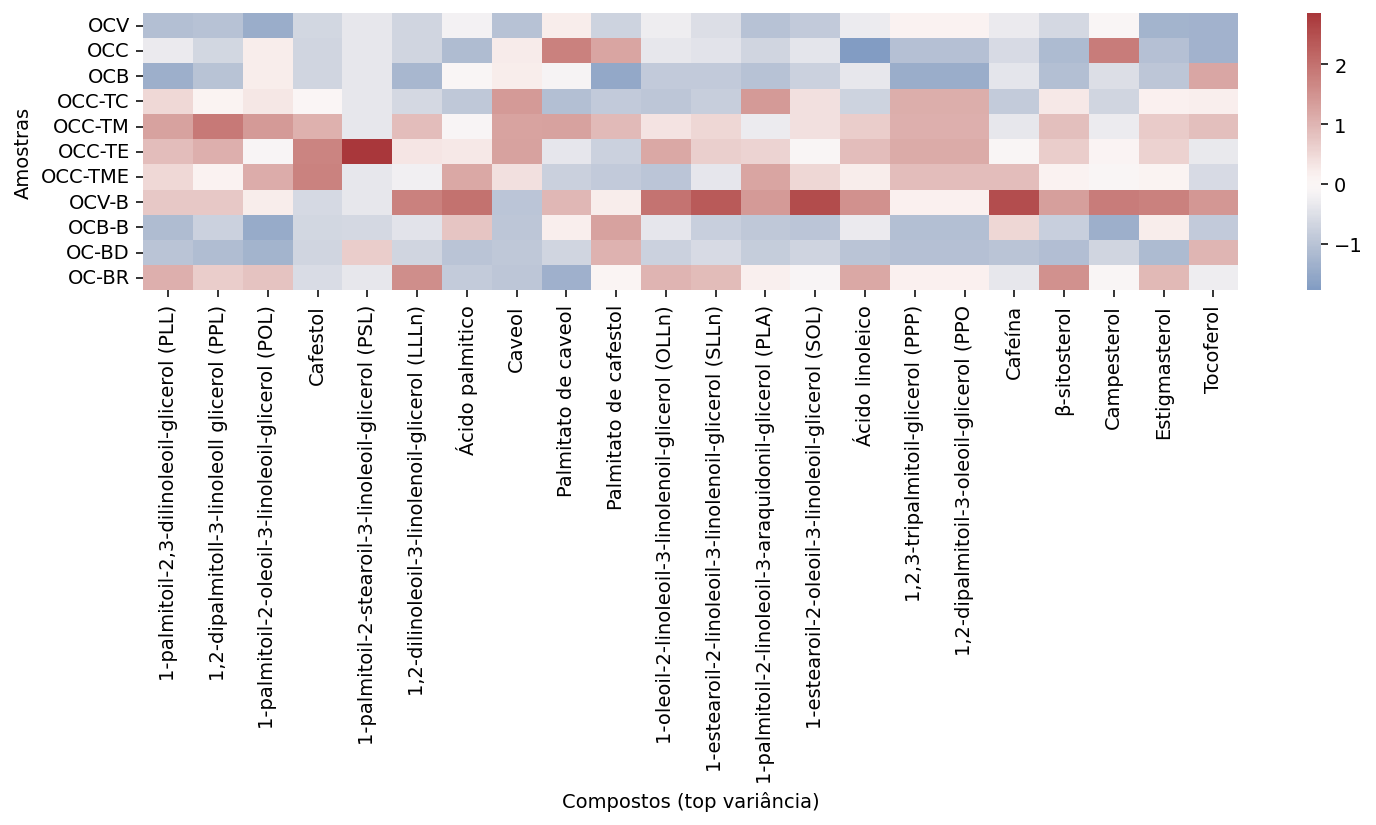

Arquivos gerados: scree, PCA, dendrograma, heatmap, testes, RF, PLS-DA/VIP.


In [20]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import LeaveOneOut, cross_val_score
from sklearn.cross_decomposition import PLSRegression
from sklearn.metrics import accuracy_score
from scipy.stats import mannwhitneyu
from scipy.cluster.hierarchy import linkage, dendrogram

# =========================
# 0) Base: imputação
# =========================
X = df_num.T  # amostras x compostos
X_imp = pd.DataFrame(SimpleImputer(strategy="median").fit_transform(X),
                     index=X.index, columns=X.columns)

roasted = ["OCC-TC","OCC-TM","OCC-TE","OCC-TME"]
non_roasted = [s for s in X_imp.index if s not in roasted]
brocado = ["OCV-B","OCB-B"]
nao_broc = ["OCV","OCB","OCC"]

# =========================
# 1) PCA + figuras
# =========================
Z = StandardScaler().fit_transform(X_imp)
pca = PCA(n_components=min(Z.shape))
scores = pca.fit_transform(Z)
expl = pca.explained_variance_ratio_

# scree
plt.figure()
plt.plot(np.arange(1, len(expl)+1), np.cumsum(expl), marker="o")
plt.xlabel("Número de componentes")
plt.ylabel("Variância explicada acumulada")
plt.ylim(0, 1.01)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("pca_scree.png", dpi=200)
plt.show()

# PC1 x PC2
plt.figure()
plt.scatter(scores[:,0], scores[:,1])
for i, name in enumerate(X_imp.index):
    plt.text(scores[i,0], scores[i,1], name, fontsize=9)
plt.xlabel(f"PC1 ({expl[0]*100:.1f}%)")
plt.ylabel(f"PC2 ({expl[1]*100:.1f}%)")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("pca_pc1_pc2.png", dpi=200)
plt.show()

# loadings top
load = pd.DataFrame({"PC1": pca.components_[0], "PC2": pca.components_[1]}, index=X_imp.columns)
top_pc1 = load["PC1"].abs().sort_values(ascending=False).head(15)
top_pc2 = load["PC2"].abs().sort_values(ascending=False).head(15)
load.loc[top_pc1.index].sort_values("PC1", key=np.abs, ascending=False).to_csv("top_loadings_PC1.csv")
load.loc[top_pc2.index].sort_values("PC2", key=np.abs, ascending=False).to_csv("top_loadings_PC2.csv")

# =========================
# 2) Cluster + heatmap
# =========================
L = linkage(Z, method="ward")
plt.figure(figsize=(10,4))
dendrogram(L, labels=X_imp.index.tolist(), leaf_rotation=90)
plt.title("Cluster hierárquico (Ward)")
plt.ylabel("Distância")
plt.tight_layout()
plt.savefig("dendrogram_ward.png", dpi=200)
plt.show()

N = min(25, df_num.shape[0])
top_var = df_num.var(axis=1).sort_values(ascending=False).head(N).index
X_hm = X_imp[top_var]
X_hm_z = (X_hm - X_hm.mean(axis=0)) / X_hm.std(axis=0)

plt.figure(figsize=(11,6))
sns.heatmap(X_hm_z, center=0, cmap="vlag")
plt.xlabel("Compostos (top variância)")
plt.ylabel("Amostras")
plt.tight_layout()
plt.savefig("heatmap_topvar.png", dpi=200)
plt.show()

# =========================
# 3) Testes (exploratórios) + efeito
# =========================
def group_test(groupA, groupB, nameA="A", nameB="B"):
    gA, gB = X_imp.loc[groupA], X_imp.loc[groupB]
    rows = []
    for comp in X_imp.columns:
        a, b = gA[comp].values, gB[comp].values
        stat, p = mannwhitneyu(a, b, alternative="two-sided")
        medA, medB = np.median(a), np.median(b)
        rows.append([comp, medA, medB, medA-medB, np.log2((medA+1e-9)/(medB+1e-9)), p])
    res = pd.DataFrame(rows, columns=["Composto",f"Med_{nameA}",f"Med_{nameB}","Δmed","log2FC","p"]).sort_values("p")
    return res

res_roast = group_test(roasted, non_roasted, "Torrado","NaoTorrado")
res_roast.to_csv("teste_torra_vs_nao.csv", index=False)

res_broca = group_test(brocado, nao_broc, "Brocado","NaoBrocado")
res_broca.to_csv("teste_brocado_vs_nao.csv", index=False)

# Rio vs Dura: só para efeito descritivo (n=1 vs 1)
res_rio_dura = group_test(["OC-BR"], ["OC-BD"], "Rio","Dura")
res_rio_dura.to_csv("descritivo_rio_vs_dura.csv", index=False)

# =========================
# 4) Random Forest (cru vs torrado) + importâncias
# =========================
y = X_imp.index.to_series().apply(lambda s: 1 if s in roasted else 0).values
rf = RandomForestClassifier(n_estimators=1000, random_state=42, class_weight="balanced")
acc = cross_val_score(rf, X_imp.values, y, cv=LeaveOneOut(), scoring="accuracy").mean()

rf.fit(X_imp.values, y)
imp = pd.Series(rf.feature_importances_, index=X_imp.columns).sort_values(ascending=False)
imp.to_csv("rf_importancias_cru_vs_torrado.csv")

with open("rf_accuracy.txt","w") as f:
    f.write(f"LOOCV_accuracy_cru_vs_torrado = {acc:.3f}\n")

# =========================
# 5) PLS-DA + VIP (cru vs torrado)
# =========================
Zdf = pd.DataFrame(StandardScaler().fit_transform(X_imp), index=X_imp.index, columns=X_imp.columns)
yfloat = y.astype(float)

def plsda_loocv(ncomp):
    loo = LeaveOneOut()
    yhat = np.zeros_like(yfloat)
    for tr, te in loo.split(Zdf):
        pls = PLSRegression(n_components=ncomp)
        pls.fit(Zdf.iloc[tr].values, yfloat[tr])
        yhat[te] = pls.predict(Zdf.iloc[te].values).ravel()
    pred = (yhat >= 0.5).astype(int)
    return accuracy_score(y, pred)

scores_pls = [(k, plsda_loocv(k)) for k in range(1,6)]
best_k = max(scores_pls, key=lambda x: x[1])[0]

pls = PLSRegression(n_components=best_k).fit(Zdf.values, yfloat)
T, W, Q = pls.x_scores_, pls.x_weights_, pls.y_loadings_
p, h = W.shape
s = np.sum((T**2) * (Q**2), axis=0)
vip = np.sqrt(p * (W**2 @ s) / np.sum(s))
vip = pd.Series(vip, index=Zdf.columns).sort_values(ascending=False)
vip.to_csv("plsda_vip_cru_vs_torrado.csv")

pd.DataFrame(scores_pls, columns=["n_components","LOOCV_acc"]).to_csv("plsda_loocv_scores.csv", index=False)

print("Arquivos gerados: scree, PCA, dendrograma, heatmap, testes, RF, PLS-DA/VIP.")

1️⃣ Biplot PCA (amostras + vetores químicos)

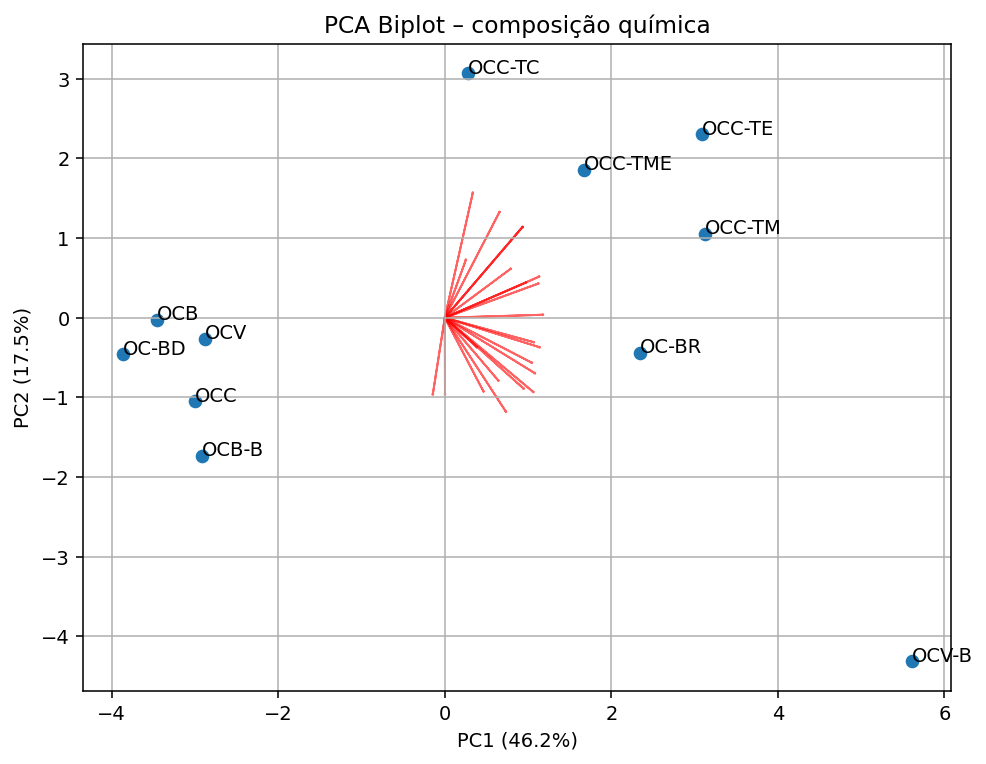

In [22]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# matriz amostras x compostos
X = df_num.T

# ===== 1) imputação =====
imp = SimpleImputer(strategy="median")
X_imp = pd.DataFrame(
    imp.fit_transform(X),
    index=X.index,
    columns=X.columns
)

# ===== 2) padronização =====
Z = StandardScaler().fit_transform(X_imp)

# ===== 3) PCA =====
pca = PCA(n_components=2)
scores = pca.fit_transform(Z)
loadings = pca.components_.T

# ===== 4) Biplot =====
plt.figure(figsize=(8,6))

# amostras
plt.scatter(scores[:,0], scores[:,1])

for i, name in enumerate(X_imp.index):
    plt.text(scores[i,0], scores[i,1], name)

# vetores dos compostos
for i, comp in enumerate(X_imp.columns):
    plt.arrow(
        0,0,
        loadings[i,0]*4,
        loadings[i,1]*4,
        color="red",
        alpha=0.6
    )

plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)")
plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)")

plt.title("PCA Biplot – composição química")

plt.grid(True)
plt.show()

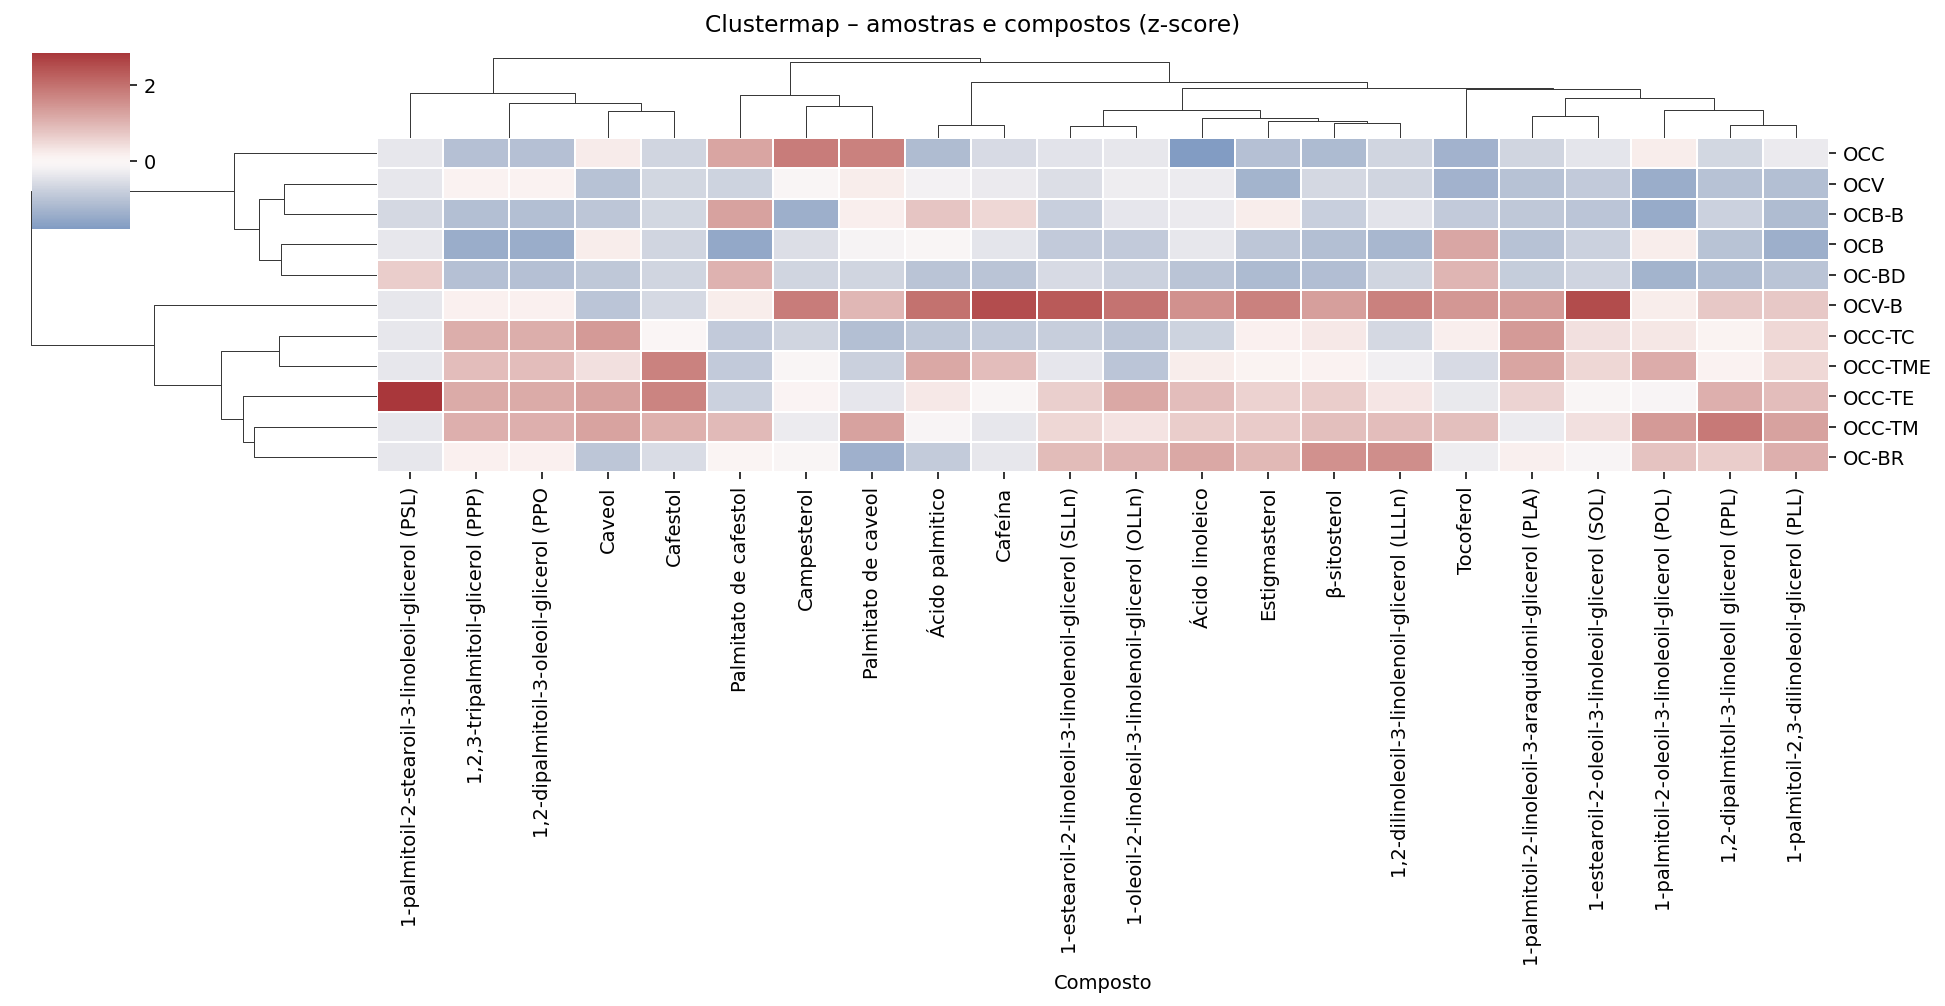

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [24]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.impute import SimpleImputer

# amostras x compostos
X = df_num.T

# imputação
X_imp = pd.DataFrame(
    SimpleImputer(strategy="median").fit_transform(X),
    index=X.index, columns=X.columns
)

# z-score por composto (coluna)
X_z = (X_imp - X_imp.mean(axis=0)) / X_imp.std(axis=0, ddof=1)
X_z = X_z.fillna(0.0)

# clustermap (Ward/Euclid é uma combinação bem usada)
g = sns.clustermap(
    X_z,
    method="ward",
    metric="euclidean",
    cmap="vlag",
    center=0,
    figsize=(14, 7),
    linewidths=0.2
)

g.fig.suptitle("Clustermap – amostras e compostos (z-score)", y=1.02)
plt.savefig("clustermap_amostras_compostos.png", dpi=300, bbox_inches="tight")
plt.show()

from google.colab import files
files.download("clustermap_amostras_compostos.png")

In [25]:
import pandas as pd

# Exemplo: se você já tem VIP e importâncias em CSV:
vip = pd.read_csv("plsda_vip_cru_vs_torrado.csv", header=None, names=["Composto","VIP"])
rf  = pd.read_csv("rf_importancias_cru_vs_torrado.csv", header=None, names=["Composto","Importancia"])

vip15 = vip.sort_values("VIP", ascending=False).head(15)
rf15  = rf.sort_values("Importancia", ascending=False).head(15)

vip15.to_latex("tab_vip_top15.tex", index=False, float_format="%.3f",
               caption="Top 15 compostos (VIP) do PLS-DA para separar cru vs. torrado.",
               label="tab:vip", longtable=False, escape=True)

rf15.to_latex("tab_rf_top15.tex", index=False, float_format="%.3f",
              caption="Top 15 compostos (importância) no Random Forest para cru vs. torrado.",
              label="tab:rf", longtable=False, escape=True)